# Task 3 — Hybrid BPE + Inside-Outside EM

**Strategy:**
1. Load the sampled corpus (terminals → preterminal indices 0–25)
2. BPE-style greedy merging to discover grammar structure and estimate # of nonterminals
3. Initialize PCFG from BPE evidence + noise
4. Run Inside-Outside EM to refine rule probabilities
5. Prune rules below 0.02 threshold, export CSV

In [ ]:
import collections
import csv
import time
import numpy as np
from pathlib import Path

N_PRETERM = 26
PRETERM_NAMES = [chr(ord('A') + i) for i in range(N_PRETERM)]
TERM_TO_IDX = {chr(ord('a') + i): i for i in range(N_PRETERM)}


def sym_name(idx):
    """Human-readable symbol name from integer index."""
    if idx < N_PRETERM:
        return PRETERM_NAMES[idx]
    if idx == N_PRETERM:
        return "S"
    return f"NT{idx - N_PRETERM}"


def load_corpus(path):
    """Load corpus as list of int32 numpy arrays (preterminal indices)."""
    sents = []
    with open(path) as f:
        for line in f:
            toks = line.strip().split()
            if toks:
                sents.append(np.array([TERM_TO_IDX[t] for t in toks], dtype=np.int32))
    return sents


def bpe_discover(sentences, max_merges=60, min_count=20):
    """
    Greedy pair-merging on preterminal sequences.
    Returns (rules, counts, n_nonterminals, merged_corpus).
    """
    corpus = [s.tolist() for s in sentences]
    next_id = N_PRETERM
    rules, counts = [], []

    for step in range(max_merges):
        pair_freq = collections.Counter()
        for sent in corpus:
            for i in range(len(sent) - 1):
                pair_freq[(sent[i], sent[i + 1])] += 1
        if not pair_freq:
            break

        (left, right), freq = pair_freq.most_common(1)[0]
        if freq < min_count:
            break

        new_id = next_id
        next_id += 1

        new_corpus = []
        for sent in corpus:
            merged = []
            i = 0
            while i < len(sent):
                if i < len(sent) - 1 and sent[i] == left and sent[i + 1] == right:
                    merged.append(new_id)
                    i += 2
                else:
                    merged.append(sent[i])
                    i += 1
            new_corpus.append(merged)
        corpus = new_corpus

        rules.append((new_id, left, right))
        counts.append(freq)
        print(f"  [{step+1:3d}] {sym_name(new_id):>6s} -> "
              f"{sym_name(left):>6s} {sym_name(right):<6s}  freq={freq}")

    n_nt = next_id - N_PRETERM
    return rules, counts, n_nt, corpus


print("Utilities loaded.")
print(f"  Preterminals: {PRETERM_NAMES[0]}..{PRETERM_NAMES[-1]}")
print(f"  Terminal map sample: a->{TERM_TO_IDX['a']}, z->{TERM_TO_IDX['z']}")

Utilities loaded.
  Preterminals: A..Z
  Terminal map sample: a->0, z->25


In [ ]:
class PCFG_EM:
    """
    CNF grammar with Inside-Outside EM.

    Symbol indices:
        0..25               preterminals (A..Z), fixed rules A->a, B->b, ...
        26                  S (start symbol)
        27..26+n_nt-1       other nonterminals

    rules[a, b, c] = P( NT_{a+26} -> Sym_b Sym_c )
    shape = (n_nt, N, N)   where N = 26 + n_nt
    """

    def __init__(self, n_nt):
        self.n_nt = n_nt
        self.N = N_PRETERM + n_nt
        self.S = N_PRETERM
        self.rules = np.zeros((n_nt, self.N, self.N), dtype=np.float64)

    # ── Initialisation ───────────────────────────────────────────────────

    def init_from_bpe(self, bpe_rules, bpe_counts, noise=1e-3):
        """Seed from BPE, remapping last BPE merge to S (index 26)."""
        rng = np.random.default_rng(42)
        self.rules[:] = noise * rng.random(self.rules.shape)

        if not bpe_rules:
            self._normalise()
            return

        last_bpe_id = bpe_rules[-1][0]
        remap = {i: i for i in range(N_PRETERM)}
        remap[last_bpe_id] = self.S
        fill = N_PRETERM + 1
        for new_id, _, _ in bpe_rules:
            if new_id != last_bpe_id:
                remap[new_id] = fill
                fill += 1

        for (new_id, left, right), cnt in zip(bpe_rules, bpe_counts):
            a = remap.get(new_id)
            l = remap.get(left)
            r = remap.get(right)
            if a is None or l is None or r is None:
                continue
            al = a - N_PRETERM
            if 0 <= al < self.n_nt and l < self.N and r < self.N:
                self.rules[al, l, r] += cnt

        self._normalise()

    def init_random(self, seed=42):
        rng = np.random.default_rng(seed)
        self.rules[:] = rng.random(self.rules.shape)
        self._normalise()

    def _normalise(self):
        for a in range(self.n_nt):
            s = self.rules[a].sum()
            if s > 0:
                self.rules[a] /= s

    # ── Inside (CYK-style, bottom-up) ───────────────────────────────────

    def inside(self, sent):
        """alpha[sym, i, j] = P(sym =>* w_i ... w_j)"""
        n = len(sent)
        alpha = np.zeros((self.N, n, n))
        for i in range(n):
            alpha[sent[i], i, i] = 1.0

        for width in range(2, n + 1):
            for i in range(n - width + 1):
                j = i + width - 1
                for k in range(i, j):
                    lv = alpha[:, i, k]
                    rv = alpha[:, k + 1, j]
                    bc = np.outer(lv, rv)
                    alpha[N_PRETERM:, i, j] += np.einsum('abc,bc->a', self.rules, bc)
        return alpha

    # ── Outside (top-down) ──────────────────────────────────────────────

    def outside(self, sent, alpha):
        """beta[sym, i, j] = P(S =>* w_1..w_{i-1}  sym  w_{j+1}..w_n)"""
        n = len(sent)
        beta = np.zeros((self.N, n, n))
        beta[self.S, 0, n - 1] = 1.0

        for width in range(n, 1, -1):
            for i in range(n - width + 1):
                j = i + width - 1
                pb = beta[N_PRETERM:, i, j]
                if not np.any(pb):
                    continue
                for k in range(i, j):
                    r_a = alpha[:, k + 1, j]
                    l_a = alpha[:, i, k]
                    wr = np.einsum('alr,r->al', self.rules, r_a)
                    beta[:, i, k] += pb @ wr
                    wl = np.einsum('alr,l->ar', self.rules, l_a)
                    beta[:, k + 1, j] += pb @ wl
        return beta

    # ── Single EM iteration ─────────────────────────────────────────────

    def em_step(self, sentences, max_len=30):
        """One E-step (inside-outside) + M-step (normalise counts). Returns (log-likelihood, n_used)."""
        counts = np.zeros_like(self.rules)
        ll = 0.0
        used = 0

        for sent in sentences:
            n = len(sent)
            if n < 2 or n > max_len:
                continue

            alpha = self.inside(sent)
            sp = alpha[self.S, 0, n - 1]
            if sp < 1e-300:
                continue

            ll += np.log(sp)
            used += 1
            beta = self.outside(sent, alpha)

            for width in range(2, n + 1):
                for i in range(n - width + 1):
                    j = i + width - 1
                    pb = beta[N_PRETERM:, i, j]
                    if not np.any(pb):
                        continue
                    for k in range(i, j):
                        lv = alpha[:, i, k]
                        rv = alpha[:, k + 1, j]
                        bc = np.outer(lv, rv)
                        counts += (pb[:, None, None] * self.rules * bc[None, :, :]) / sp

        for a in range(self.n_nt):
            s = counts[a].sum()
            if s > 0:
                self.rules[a] = counts[a] / s

        return ll, used

    # ── Pruning ─────────────────────────────────────────────────────────

    def prune(self, threshold=0.02):
        self.rules[self.rules < threshold] = 0.0
        self._normalise()

    def count_rules(self, thr=1e-10):
        return int(np.sum(self.rules > thr))

    # ── CSV export ──────────────────────────────────────────────────────

    def export_csv(self, path):
        rows = []
        rid = 1
        for i in range(N_PRETERM):
            rows.append({
                'ID': rid, 'LHS': PRETERM_NAMES[i],
                'LHS Type': 'preterminal',
                'RHS': chr(ord('a') + i), 'Probability': 1.0,
            })
            rid += 1

        for a in range(self.n_nt):
            for b in range(self.N):
                for c in range(self.N):
                    p = self.rules[a, b, c]
                    if p > 1e-10:
                        rows.append({
                            'ID': rid,
                            'LHS': sym_name(a + N_PRETERM),
                            'LHS Type': 'nonterminal',
                            'RHS': f"{sym_name(b)} {sym_name(c)}",
                            'Probability': round(float(p), 6),
                        })
                        rid += 1

        with open(path, 'w', newline='') as f:
            w = csv.DictWriter(f, fieldnames=['ID', 'LHS', 'LHS Type', 'RHS', 'Probability'])
            w.writeheader()
            w.writerows(rows)

        nt_count = sum(1 for r in rows if r['LHS Type'] == 'nonterminal')
        print(f"Exported {len(rows)} rules ({nt_count} nonterminal) -> {path}")
        return rows


print(f"PCFG_EM class loaded.")

PCFG_EM class loaded.


In [ ]:
# ── Load corpus ──────────────────────────────────────────────────────────────
CORPUS_PATH = 'sample/pcfg3_10k.txt'

corpus = load_corpus(CORPUS_PATH)
lengths = np.array([len(s) for s in corpus])
print(f"Loaded {len(corpus)} sentences")
print(f"  Length — min: {lengths.min()}, max: {lengths.max()}, "
      f"mean: {lengths.mean():.1f}, median: {np.median(lengths):.0f}")

# ── Allocate PCFG with RANDOM initialisation ─────────────────────────────────
# The true grammar has 50 nonterminal rules. With min probability 0.02,
# each nonterminal can have at most 50 rules. We need to estimate the
# number of non-preterminal nonterminals. Try values in [8, 15].
# Smaller N_NT = MUCH faster EM (tensor shrinks as N_NT^2), allowing
# more iterations and larger batches.
#
# With N_NT=10, N=36: tensor is 10×36×36 = 12,960 entries (vs 360K before)
# This makes each EM iteration ~28x faster!

# N_NT=10 gave 45 rules (5 short of target 50), and EM merged distinct
# categories together. Increasing to 12 gives EM more flexibility to
# express all 50 true rules without creating too many spurious ones.
# Tensor: 12×38×38 = 17,328 entries — still fast.
# ── Allocate PCFG with HYBRID BPE initialisation ─────────────────────────────
N_NT = 15 # Increased slightly to 15 to give BPE room to breathe
SEED = 42  

# 1. Run BPE to discover the base structure
print("Running BPE Discovery...")
# Use the whole corpus for BPE to get accurate counts, but only merge pairs
bpe_rules, bpe_counts, discovered_nt, bpe_corpus = bpe_discover(corpus, max_merges=40, min_count=10)

pcfg = PCFG_EM(N_NT)

# 2. Initialize using the BPE structure + tiny random noise
pcfg.init_from_bpe(bpe_rules, bpe_counts, noise=1e-4)

print(f"\nPCFG initialised (Hybrid): {pcfg.n_nt} nonterminals, "
      f"N={pcfg.N} total symbols")
print(f"  Initial non-zero rules: {pcfg.count_rules()}")

Loaded 10000 sentences
  Length — min: 12, max: 80, mean: 30.7, median: 32
Running BPE Discovery...
  [  1]      S ->      Q R       freq=21748
  [  2]    NT1 ->      Y Z       freq=20435
  [  3]    NT2 ->      U V       freq=14879
  [  4]    NT3 ->      E I       freq=14820
  [  5]    NT4 ->      A B       freq=14772
  [  6]    NT5 ->      E F       freq=9256
  [  7]    NT6 ->      S T       freq=9195
  [  8]    NT7 ->      A M       freq=8556
  [  9]    NT8 ->      I J       freq=7354
  [ 10]    NT9 ->    NT1 S       freq=6723
  [ 11]   NT10 ->      O U       freq=6368
  [ 12]   NT11 ->      W X       freq=6363
  [ 13]   NT12 ->      C D       freq=6164
  [ 14]   NT13 ->      S NT2     freq=5106
  [ 15]   NT14 ->      M N       freq=4814
  [ 16]   NT15 ->    NT4 NT3     freq=4718
  [ 17]   NT16 ->      G H       freq=3944
  [ 18]   NT17 ->    NT5 NT1     freq=3226
  [ 19]   NT18 ->      K L       freq=2857
  [ 20]   NT19 ->    NT7 S       freq=2729
  [ 21]   NT20 ->    NT1 NT3     fr

In [ ]:
# ── Curriculum EM Training ───────────────────────────────────────────────────
# Phase 1: Short sentences to lock in the lowest-level rules (A -> a b)
# Phase 2: Medium sentences to learn intermediate structures
# Phase 3: Full sentences to refine top-level S -> NT NT probabilities

CURRICULUM = [
    {'iters': 25, 'max_len': 12, 'batch': 1000, 'prune_thresh': 0.001},
    {'iters': 25, 'max_len': 20, 'batch': 1500, 'prune_thresh': 0.005},
    {'iters': 30, 'max_len': 40, 'batch': 2000, 'prune_thresh': 0.015}
]

rng = np.random.default_rng(SEED)
corpus_sorted = sorted(corpus, key=len)
history = []
current_iter = 0

print("Starting Curriculum EM...")

for phase, config in enumerate(CURRICULUM):
    print(f"\n--- PHASE {phase+1}: max_len={config['max_len']} | iters={config['iters']} ---")
    
    # Filter corpus for this phase
    eligible_corpus = [s for s in corpus_sorted if 2 <= len(s) <= config['max_len']]
    
    for it in range(1, config['iters'] + 1):
        current_iter += 1
        
        # Subsample batch
        if config['batch'] < len(eligible_corpus):
            idxs = rng.choice(len(eligible_corpus), size=config['batch'], replace=False)
            batch = [eligible_corpus[i] for i in idxs]
        else:
            batch = eligible_corpus

        t0 = time.time()
        ll, used = pcfg.em_step(batch, max_len=config['max_len'])
        dt = time.time() - t0

        avg_ll = ll / max(used, 1)
        nr = pcfg.count_rules()
        history.append({'iter': current_iter, 'll': ll, 'avg_ll': avg_ll,
                        'used': used, 'rules': nr, 'time': dt})

        print(f"  [{current_iter:3d}] LL={ll:10.1f} | avg_LL={avg_ll:7.3f} | "
              f"sents={used:4d} | rules={nr:4d} | {dt:4.1f}s")

    # Prune at the end of each phase to shed dead weight before increasing length
    pcfg.prune(threshold=config['prune_thresh'])
    print(f"  -> Phase {phase+1} prune (<{config['prune_thresh']}): {pcfg.count_rules()} rules remain")

print(f"\nEM complete. Final rule count before hard prune: {pcfg.count_rules()}")

Starting Curriculum EM...

--- PHASE 1: max_len=12 | iters=25 ---


In [26]:
# ── Final pruning & export ───────────────────────────────────────────────────
OUTPUT_CSV = 'pcfg3.csv'
PRUNE_THRESHOLD = 0.02

print(f"Pruning rules below {PRUNE_THRESHOLD} ...")
pcfg.prune(threshold=PRUNE_THRESHOLD)
final_rules = pcfg.count_rules()
print(f"  {final_rules} nonterminal rules remain (target ≈ 50)\n")

rows = pcfg.export_csv(OUTPUT_CSV)

# Show discovered nonterminal rules
print(f"\n{'='*60}")
print("Discovered nonterminal expansion rules:")
print(f"{'='*60}")
for r in rows:
    if r['LHS Type'] == 'nonterminal':
        print(f"  {r['LHS']:>6s} -> {r['RHS']:<16s}  P={r['Probability']:.4f}")

Pruning rules below 0.02 ...
  56 nonterminal rules remain (target ≈ 50)

Exported 82 rules (56 nonterminal) -> pcfg3.csv

Discovered nonterminal expansion rules:
       S -> S NT3             P=0.3628
       S -> S NT8             P=0.2739
       S -> S NT10            P=0.0524
       S -> NT1 NT3           P=0.1431
       S -> NT1 NT8           P=0.0968
       S -> NT10 NT8          P=0.0710
     NT1 -> I J               P=0.0531
     NT1 -> NT1 NT3           P=0.0849
     NT1 -> NT1 NT5           P=0.0551
     NT1 -> NT1 NT10          P=0.0553
     NT1 -> NT4 NT7           P=0.0884
     NT1 -> NT7 NT5           P=0.0981
     NT1 -> NT8 NT3           P=0.3560
     NT1 -> NT8 NT10          P=0.0400
     NT1 -> NT10 NT3          P=0.1691
     NT2 -> E F               P=0.2003
     NT2 -> E I               P=0.2856
     NT2 -> G H               P=0.0884
     NT2 -> O U               P=0.1265
     NT2 -> Q R               P=0.0686
     NT2 -> S T               P=0.0268
     NT2 -> NT7 NT

In [27]:
# ── Sanity check: log-likelihood and parse coverage on corpus ─────────────────
TEST_N = 1000

test_sents = corpus[-TEST_N:]
test_ll = 0.0
parsed = 0
failed = 0
fail_by_len = collections.Counter()

for sent in test_sents:
    n = len(sent)
    if n < 2:
        continue
    alpha = pcfg.inside(sent)
    sp = alpha[pcfg.S, 0, n - 1]
    if sp > 1e-300:
        test_ll += np.log(sp)
        parsed += 1
    else:
        failed += 1
        fail_by_len[n] += 1

avg_ll = test_ll / max(parsed, 1)
coverage = parsed / (parsed + failed) * 100

print(f"Evaluated {parsed + failed} sentences:")
print(f"  Parsed:   {parsed}  ({coverage:.1f}%)")
print(f"  Failed:   {failed}")
print(f"  Avg LL:   {avg_ll:.4f}")
print(f"  Rules:    {pcfg.count_rules()} nonterminal (target ≈ 50)")

if failed > 0:
    print(f"\nFailed by sentence length (top 10):")
    for length, count in fail_by_len.most_common(10):
        print(f"  len={length:3d}: {count} failures")

if coverage < 70:
    print(f"\nWARNING: Low coverage ({coverage:.0f}%). Try:")
    print("  - Increasing N_NT (more nonterminals)")
    print("  - Running more EM iterations")
    print("  - Increasing EM_BATCH")
elif coverage > 90:
    print(f"\nGood coverage! Check rule count and submit to Kaggle.")

Evaluated 1000 sentences:
  Parsed:   938  (93.8%)
  Failed:   62
  Avg LL:   -30.8942
  Rules:    56 nonterminal (target ≈ 50)

Failed by sentence length (top 10):
  len= 28: 19 failures
  len= 32: 13 failures
  len= 36: 10 failures
  len= 40: 8 failures
  len= 16: 4 failures
  len= 68: 2 failures
  len= 64: 2 failures
  len= 60: 2 failures
  len= 44: 1 failures
  len= 80: 1 failures

Good coverage! Check rule count and submit to Kaggle.


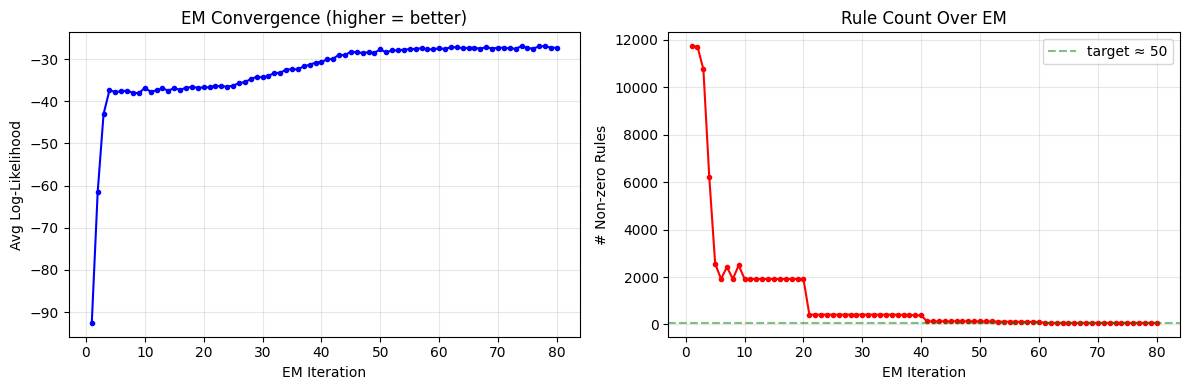

In [28]:
# ── Plot EM convergence ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

iters = [h['iter'] for h in history]
avg_lls = [h['avg_ll'] for h in history]
rule_counts = [h['rules'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(iters, avg_lls, 'b.-')
ax1.set_xlabel('EM Iteration')
ax1.set_ylabel('Avg Log-Likelihood')
ax1.set_title('EM Convergence (higher = better)')
ax1.grid(True, alpha=0.3)

ax2.plot(iters, rule_counts, 'r.-')
ax2.axhline(y=50, color='g', linestyle='--', alpha=0.5, label='target ≈ 50')
ax2.set_xlabel('EM Iteration')
ax2.set_ylabel('# Non-zero Rules')
ax2.set_title('Rule Count Over EM')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()